In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\PC\anaconda3\envs\noshow\python.exe
3.12.14 | packaged by conda-forge | (main, Sep  2 2026, 23:18:20) [MSC v.1944 64 bit (AMD64)]


In [2]:
import hashlib
import pandas as pd

PATH = "data/KaggleV2-May-2016.csv"
EXPECTED_SHA256 = "9132d3e7d0246617df9041d3764f20ad6f08e7b0d9f0997fa254fc5e52eda27d"  # from certutil

# 1. Integrity: Python's fingerprint must match certutil's
with open(PATH, "rb") as f:
    sha = hashlib.sha256(f.read()).hexdigest()
print("SHA-256 matches certutil:", sha == EXPECTED_SHA256)

# 2. Structure
df = pd.read_csv(PATH)
print("Shape:", df.shape, "(expected (110527, 14))")
print("Columns:", list(df.columns))
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique AppointmentIDs:", df["AppointmentID"].nunique())
print("Unique patients:", df["PatientId"].nunique())

# 3. Target balance: tests Kaggle's '30% miss' claim
print("\nNo-show share:")
print(df["No-show"].value_counts(normalize=True).round(4))

# 4. Which date column is which? (Kaggle's dictionary may swap them)
print("\nScheduledDay range:  ", df["ScheduledDay"].min(), "->", df["ScheduledDay"].max())
print("AppointmentDay range:", df["AppointmentDay"].min(), "->", df["AppointmentDay"].max())

SHA-256 matches certutil: True
Shape: (110527, 14) (expected (110527, 14))
Columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']
Missing values: 0
Duplicate rows: 0
Unique AppointmentIDs: 110527
Unique patients: 62299

No-show share:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64

ScheduledDay range:   2015-11-10T07:13:56Z -> 2016-06-08T20:07:23Z
AppointmentDay range: 2016-04-29T00:00:00Z -> 2016-06-08T00:00:00Z


In [3]:
# ---- DATA QUALITY AUDIT (read-only: nothing in df is changed) ----

# 1. Age: are there impossible values?
print("Age min/max:", df["Age"].min(), "/", df["Age"].max())
print("Ages below 0:", (df["Age"] < 0).sum())
print("Age exactly 0:", (df["Age"] == 0).sum())
print("Ages above 100:", sorted(df.loc[df["Age"] > 100, "Age"].tolist()))

# 2. Columns that should be yes/no (0/1): do they contain anything else?
for col in ["Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap", "SMS_received"]:
    print(f"\n{col}:", df[col].value_counts().sort_index().to_dict())

# 3. Gender and Neighbourhood
print("\nGender:", df["Gender"].value_counts().to_dict())
print("Neighbourhoods:", df["Neighbourhood"].nunique())
print("Smallest neighbourhoods:", df["Neighbourhood"].value_counts().tail(5).to_dict())

# 4. Lead time: raw vs date-only calculation
sched = pd.to_datetime(df["ScheduledDay"])
appt = pd.to_datetime(df["AppointmentDay"])
lead_raw = (appt - sched).dt.days
lead_dates = (appt.dt.normalize() - sched.dt.normalize()).dt.days
print("\nNegative lead times (raw subtraction):", (lead_raw < 0).sum())
print("Negative lead times (dates only):", (lead_dates < 0).sum())
print("Same-day appointments (lead = 0):", (lead_dates == 0).sum())
print("Lead time max (days):", lead_dates.max())

# 5. Which weekdays have appointments?
print("\nAppointment weekdays:", appt.dt.day_name().value_counts().to_dict())

Age min/max: -1 / 115
Ages below 0: 1
Age exactly 0: 3539
Ages above 100: [102, 102, 115, 115, 115, 115, 115]

Scholarship: {0: 99666, 1: 10861}

Hipertension: {0: 88726, 1: 21801}

Diabetes: {0: 102584, 1: 7943}

Alcoholism: {0: 107167, 1: 3360}

Handcap: {0: 108286, 1: 2042, 2: 183, 3: 13, 4: 3}

SMS_received: {0: 75045, 1: 35482}

Gender: {'F': 71840, 'M': 38687}
Neighbourhoods: 81
Smallest neighbourhoods: {'ILHA DO BOI': 35, 'ILHA DO FRADE': 10, 'AEROPORTO': 8, 'ILHAS OCEÂNICAS DE TRINDADE': 2, 'PARQUE INDUSTRIAL': 1}

Negative lead times (raw subtraction): 38568
Negative lead times (dates only): 5
Same-day appointments (lead = 0): 38563
Lead time max (days): 179

Appointment weekdays: {'Wednesday': 25867, 'Tuesday': 25640, 'Monday': 22715, 'Friday': 19019, 'Thursday': 17247, 'Saturday': 39}


In [4]:
# Who are the age-115 records?
age115 = df[df["Age"] == 115]
print("Rows with Age 115:", len(age115), "| distinct patients:", age115["PatientId"].nunique())
print(age115[["PatientId", "Gender", "Neighbourhood", "AppointmentDay"]])

# The 5 impossible bookings (appointment before booking date)
bad = df[lead_dates < 0]
print("\nAppointments dated before their booking:")
print(bad[["PatientId", "ScheduledDay", "AppointmentDay", "No-show"]])

Rows with Age 115: 5 | distinct patients: 2
          PatientId Gender Neighbourhood        AppointmentDay
63912  3.196321e+13      F    ANDORINHAS  2016-05-19T00:00:00Z
63915  3.196321e+13      F    ANDORINHAS  2016-05-19T00:00:00Z
68127  3.196321e+13      F    ANDORINHAS  2016-05-16T00:00:00Z
76284  3.196321e+13      F    ANDORINHAS  2016-05-30T00:00:00Z
97666  7.482346e+14      F      SÃO JOSÉ  2016-06-03T00:00:00Z

Appointments dated before their booking:
          PatientId          ScheduledDay        AppointmentDay No-show
27033  7.839273e+12  2016-05-10T10:51:53Z  2016-05-09T00:00:00Z     Yes
55226  7.896294e+12  2016-05-18T14:50:41Z  2016-05-17T00:00:00Z     Yes
64175  2.425226e+13  2016-05-05T13:43:58Z  2016-05-04T00:00:00Z     Yes
71533  9.982316e+14  2016-05-11T13:49:20Z  2016-05-05T00:00:00Z     Yes
72362  3.787482e+12  2016-05-04T06:50:57Z  2016-05-03T00:00:00Z     Yes


## Data cleaning plan (agreed after the quality audit)

| # | Action | Rows | Reason |
|---|---|---|---|
| 1 | Drop Age = −1 | 1 | Impossible value |
| 2 | Keep Age = 0 | — | Infants under 1 year are valid patients |
| 3 | Drop Age = 115 (2 patients, 5 rows); keep Age 102 | 5 | Implausible and unverifiable; 0.005% of data |
| 4 | Handcap → yes/no (> 0) | 2,241 in raw data; 2,235 after drops | Meaning of 0–4 undocumented; levels 3–4 have only 16 rows |
| 5 | Lead time from **dates only** | all | Raw subtraction mislabels 38,563 same-day visits as negative |
| 6 | Drop appointments dated before booking | 5 | Impossible order; all 5 are no-shows, so keeping them would leak the target |
| 7 | Group rare neighbourhoods into "OTHER" | 11 neighbourhoods, 555 training rows (0.96%) | Fewer than 100 advance-booking appointments in training; rates too unreliable below this (±9 pts). Decided from training data only (see Q4) |
| 8 | Keep Saturdays (39 rows) | — | Noted as a limitation |
| 9 | PatientId stored as text | all | 5 IDs contain decimals (malformed, 1 appointment each, no collisions); text keeps every ID exactly as in the source |
| 10 | Keep same-second multi-bookings (2,607 rows, 1,274 groups) | — | Likely several services booked together: 29 groups have mixed outcomes, consistent with the author's health-records experience that simultaneous bookings are usually multi-service (lab, pharmacy, consultation). Cannot be verified here (no service-type column). Patient-grouped split prevents leakage; robustness check on a one-row-per-group version at the end |

Expected: 11 rows dropped (110,527 → 110,516).

In [5]:
# ---- APPLY CLEANING PLAN (df is left untouched; result goes into `clean`) ----
n0 = len(df)
assert n0 == 110527

# Dates (step 5): booking keeps its time; both reduced to dates for lead time
scheduled = pd.to_datetime(df["ScheduledDay"])
appointment = pd.to_datetime(df["AppointmentDay"]).dt.normalize()
lead_days = (appointment - scheduled.dt.normalize()).dt.days

# Rows to drop (steps 1, 3, 6)
drop_age_neg = df["Age"] < 0
drop_age_115 = df["Age"] == 115
drop_lead_neg = lead_days < 0
drop_mask = drop_age_neg | drop_age_115 | drop_lead_neg
print("Age -1:", drop_age_neg.sum(), "| Age 115:", drop_age_115.sum(),
      "| Appointment before booking:", drop_lead_neg.sum(), "| Total:", drop_mask.sum())
assert drop_age_neg.sum() == 1 and drop_age_115.sum() == 5 and drop_lead_neg.sum() == 5
assert drop_mask.sum() == 11, "Overlap between rules: investigate before continuing"

# Build the clean table with clear, consistent column names
keep = ~drop_mask
clean = pd.DataFrame({
    "patient_id":       df.loc[keep, "PatientId"],
    "appointment_id":   df.loc[keep, "AppointmentID"],
    "gender":           df.loc[keep, "Gender"],
    "scheduled_dt":     scheduled[keep],
    "appointment_date": appointment[keep],
    "lead_days":        lead_days[keep],
    "age":              df.loc[keep, "Age"],
    "neighbourhood":    df.loc[keep, "Neighbourhood"],
    "scholarship":      df.loc[keep, "Scholarship"],
    "hypertension":     df.loc[keep, "Hipertension"],

    "diabetes":         df.loc[keep, "Diabetes"],
    "alcoholism":       df.loc[keep, "Alcoholism"],
    "has_handicap":     (df.loc[keep, "Handcap"] > 0).astype(int),   # step 4
    "sms_received":     df.loc[keep, "SMS_received"],
    "missed":           (df.loc[keep, "No-show"] == "Yes").astype(int),  # 1 = did NOT attend
}).reset_index(drop=True)

# Step 9: convert PatientId only if every value is a whole number
non_whole = (clean["patient_id"] % 1 != 0).sum()
print("PatientIds that are not whole numbers:", non_whole)
if non_whole == 0:
    clean["patient_id"] = clean["patient_id"].astype("int64")
else:
    print("-> NOT converted. Stop here and review these IDs before deciding.")

# Verification
assert len(clean) == 110516
assert clean["lead_days"].min() >= 0
assert clean["age"].between(0, 102).all()
print("\nRows:", n0, "->", len(clean), f"(dropped {n0 - len(clean)})")
print("has_handicap = 1:", clean["has_handicap"].sum())
print("Missed rate after cleaning:", round(clean["missed"].mean(), 4))
print("Lead days range:", clean["lead_days"].min(), "to", clean["lead_days"].max())
print("Same-day appointments kept:", (clean["lead_days"] == 0).sum())

Age -1: 1 | Age 115: 5 | Appointment before booking: 5 | Total: 11
PatientIds that are not whole numbers: 5
-> NOT converted. Stop here and review these IDs before deciding.

Rows: 110527 -> 110516 (dropped 11)
has_handicap = 1: 2235
Missed rate after cleaning: 0.2019
Lead days range: 0 to 179
Same-day appointments kept: 38561


In [6]:
# 1. Confirm the two small differences come from the dropped rows
print("Dropped rows with Handcap > 0:", (df.loc[drop_mask, "Handcap"] > 0).sum(), "(expect 6)")
print("Dropped rows that were same-day:", (lead_days[drop_mask] == 0).sum(), "(expect 2)")

# 2. Inspect the non-whole PatientIds
odd = clean[clean["patient_id"] % 1 != 0]
print("\nNon-whole PatientIds:")
print(odd[["patient_id", "appointment_id", "age", "gender", "neighbourhood", "missed"]].to_string())

# 3. Does any of them collide with a real ID if the decimal is removed?
whole_ids = set(clean.loc[clean["patient_id"] % 1 == 0, "patient_id"].astype("int64"))
for pid in odd["patient_id"].unique():
    print(f"{pid!r}: appointments = {(clean['patient_id'] == pid).sum()}, "
          f"truncated {int(pid)} already exists? {int(pid) in whole_ids}")

Dropped rows with Handcap > 0: 6 (expect 6)
Dropped rows that were same-day: 2 (expect 2)

Non-whole PatientIds:
          patient_id  appointment_id  age gender   neighbourhood  missed
3950     93779.52927         5712759   33      F          CENTRO       0
73220   537615.28476         5637728   14      F  FORTE SÃO JOÃO       0
73295   141724.16655         5637648   12      M  FORTE SÃO JOÃO       0
100506   39217.84439         5751990   44      F    PRAIA DO SUÁ       0
105419   43741.75652         5760144   39      M     MARIA ORTIZ       0
np.float64(93779.52927): appointments = 1, truncated 93779 already exists? False
np.float64(537615.28476): appointments = 1, truncated 537615 already exists? False
np.float64(141724.16655): appointments = 1, truncated 141724 already exists? False
np.float64(39217.84439): appointments = 1, truncated 39217 already exists? False
np.float64(43741.75652): appointments = 1, truncated 43741 already exists? False


In [7]:
# Step 9 (revised): PatientId stored as text, no identifier value altered
before = clean["patient_id"].nunique()
clean["patient_id"] = clean["patient_id"].apply(
    lambda x: str(int(x)) if x % 1 == 0 else str(x)
)
assert clean["patient_id"].nunique() == before, "Conversion merged or split patients"
print("Distinct patients before/after:", before, "/", clean["patient_id"].nunique())
print(clean.loc[[3950, 73220, 73295, 100506, 105419], "patient_id"].tolist())
print(clean["patient_id"].head(3).tolist())

Distinct patients before/after: 62296 / 62296
['93779.52927', '537615.28476', '141724.16655', '39217.84439', '43741.75652']
['29872499824296', '558997776694438', '4262962299951']


In [8]:
# ---- 1. Which patients disappeared entirely? (expect 3) ----
dropped_pids = set(df.loc[drop_mask, "PatientId"])
kept_pids = set(df.loc[~drop_mask, "PatientId"])
fully_removed = dropped_pids - kept_pids
print("Patients removed entirely:", len(fully_removed))
print(df.loc[df["PatientId"].isin(fully_removed),
             ["PatientId", "Age", "ScheduledDay", "AppointmentDay", "No-show"]].to_string())
assert df["PatientId"].nunique() - len(fully_removed) == clean["patient_id"].nunique()
print("Patient count reconciles: 62,299 -", len(fully_removed), "=", clean["patient_id"].nunique())

# ---- 2. Save the cleaned dataset ----
OUT = "data/appointments_clean.csv"
clean.to_csv(OUT, index=False)

# ---- 3. Reload it and prove it matches what we saved ----
check = pd.read_csv(OUT, dtype={"patient_id": str},
                    parse_dates=["scheduled_dt", "appointment_date"])
assert check.shape == clean.shape
assert list(check.columns) == list(clean.columns)
assert (check["patient_id"] == clean["patient_id"]).all()
assert (check["scheduled_dt"] == clean["scheduled_dt"]).all()
assert (check["appointment_date"] == clean["appointment_date"]).all()
assert (check["lead_days"] == clean["lead_days"]).all()
assert check["missed"].sum() == clean["missed"].sum()
print("\nReloaded file matches `clean`:", check.shape)

# ---- 4. Fingerprint the cleaned file ----
with open(OUT, "rb") as f:
    print("SHA-256 of appointments_clean.csv:", hashlib.sha256(f.read()).hexdigest())

Patients removed entirely: 3
          PatientId  Age          ScheduledDay        AppointmentDay No-show
63912  3.196321e+13  115  2016-05-16T09:17:44Z  2016-05-19T00:00:00Z     Yes
63915  3.196321e+13  115  2016-05-16T09:17:44Z  2016-05-19T00:00:00Z     Yes
68127  3.196321e+13  115  2016-04-08T14:29:17Z  2016-05-16T00:00:00Z     Yes
76284  3.196321e+13  115  2016-05-30T09:44:51Z  2016-05-30T00:00:00Z      No
97666  7.482346e+14  115  2016-05-19T07:57:56Z  2016-06-03T00:00:00Z      No
99832  4.659432e+14   -1  2016-06-06T08:58:13Z  2016-06-06T00:00:00Z      No
Patient count reconciles: 62,299 - 3 = 62296

Reloaded file matches `clean`: (110516, 15)
SHA-256 of appointments_clean.csv: ab148bd84e05fc1528cc2889f82f14b33ea379770a87f261e68292c4a5bfa0f5


In [9]:
# ---- DOUBLE-BOOKING AUDIT (read-only) ----
key = ["patient_id", "scheduled_dt", "appointment_date"]
dup = clean.duplicated(key, keep=False)
groups = clean[dup].groupby(key).size()

print("Rows in exact double bookings:", dup.sum(), f"({dup.mean():.2%} of data)")
print("Number of such groups:", len(groups))
print("Group sizes:", groups.value_counts().sort_index().to_dict())

# Do the copies agree on the outcome?
agree = clean[dup].groupby(key)["missed"].nunique().eq(1)
print("Groups where all copies have the same outcome:", agree.sum(), "of", len(groups))

# Is the no-show rate different for double-booked rows?
print("\nMissed rate, double-booked rows:", round(clean.loc[dup, "missed"].mean(), 4))
print("Missed rate, all other rows:    ", round(clean.loc[~dup, "missed"].mean(), 4))

# Wider view: same patient, same appointment day, any booking time
dup_day = clean.duplicated(["patient_id", "appointment_date"], keep=False)
print("\nRows sharing patient + appointment day (any booking time):", dup_day.sum(),
      f"({dup_day.mean():.2%})")

Rows in exact double bookings: 2607 (2.36% of data)
Number of such groups: 1274
Group sizes: {2: 1222, 3: 50, 6: 1, 7: 1}
Groups where all copies have the same outcome: 1245 of 1274

Missed rate, double-booked rows: 0.3399
Missed rate, all other rows:     0.1985

Rows sharing patient + appointment day (any booking time): 16196 (14.65%)


## Train/test split (before any exploration)

To avoid data snooping, the test set is separated **before** exploratory analysis and is not examined until final evaluation.
- Split **by patient** (GroupShuffleSplit): every patient's appointments fall entirely in train or test, so the model is never tested on patients it has seen.
- 80% of patients to train, 20% to test; random seed 42 for reproducibility.
- The test set's appointment IDs are saved to `data/test_appointment_ids.csv` so the split can be verified and recreated.

In [10]:
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(clean, groups=clean["patient_id"]))
train = clean.iloc[train_idx].reset_index(drop=True)
test = clean.iloc[test_idx].reset_index(drop=True)

# Checks
assert len(train) + len(test) == len(clean)
assert set(train["patient_id"]).isdisjoint(set(test["patient_id"])), "Patient in both sets!"

for name, part in [("Train", train), ("Test", test)]:
    print(f"{name}: {len(part):,} rows ({len(part)/len(clean):.1%}), "
          f"{part['patient_id'].nunique():,} patients, missed rate {part['missed'].mean():.4f}")

# Save the test IDs so the split is verifiable
test[["appointment_id"]].to_csv("data/test_appointment_ids.csv", index=False)
print("\nSaved", len(test), "test appointment IDs.")

Train: 88,401 rows (80.0%), 49,836 patients, missed rate 0.2012
Test: 22,115 rows (20.0%), 12,460 patients, missed rate 0.2046

Saved 22115 test appointment IDs.


## Exploratory analysis (training set only)

### Q1. Does the time between booking and appointment affect no-shows?

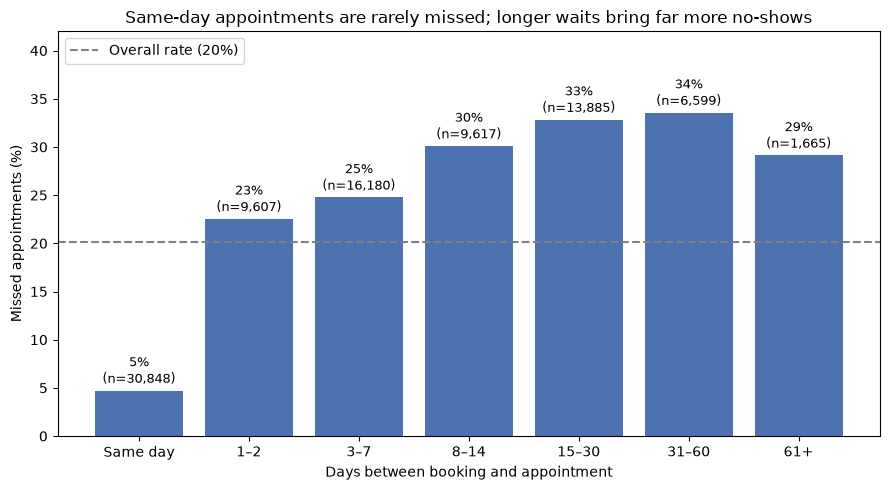

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(q1.index.astype(str), q1["rate"] * 100, color="#4C72B0")
ax.axhline(train["missed"].mean() * 100, ls="--", color="grey", label="Overall rate (20%)")
for i, (r, n) in enumerate(zip(q1["rate"], q1["n"])):
    ax.text(i, r * 100 + 0.8, f"{r:.0%}\n(n={n:,})", ha="center", fontsize=9)
ax.set_ylim(0, 42)
ax.set_xlabel("Days between booking and appointment")
ax.set_ylabel("Missed appointments (%)")
ax.set_title("Same-day appointments are rarely missed; longer waits bring far more no-shows")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("images/q1_lead_time.png", dpi=150)
plt.show()

**Finding (Q1):** Patients booked in advance are far more likely to miss their appointment than same-day patients, who are usually registered on arrival (5% missed, n=30,848). Among advance bookings, the risk rises with waiting time, from 23% at 1–2 days to about a third for waits of two weeks or more (61+ days: 29%, small group, n=1,665).

**Domain note:** Same-day appointments are typically registered on arrival (author's health-records experience), so their low rate reflects the patient already being present, not a short wait.

**Implication for modelling:** The model's purpose (reminders, overbooking) only applies to advance bookings. Performance will be reported separately for appointments with lead time ≥ 1 day, so that easy same-day cases don't inflate the scores.

### Q2. Do SMS reminders reduce no-shows?

a) Missed rate by SMS (all training data):
               rate      n
sms_received              
0             0.167  60077
1             0.273  28324 

b) Share of appointments that received an SMS, by lead band:
lead_band
Same day    0.000
1–2         0.000
3–7         0.571
8–14        0.581
15–30       0.605
31–60       0.610
61+         0.643
Name: sms_received, dtype: float64 

c) Missed rate by SMS within each lead band:
               rate              n        
sms_received      0      1       0       1
lead_band                                 
1–2           0.225    NaN  9607.0     NaN
3–7           0.267  0.233  6944.0  9236.0
8–14          0.335  0.276  4027.0  5590.0
15–30         0.374  0.299  5482.0  8403.0
31–60         0.376  0.310  2574.0  4025.0
61+           0.353  0.257   595.0  1070.0


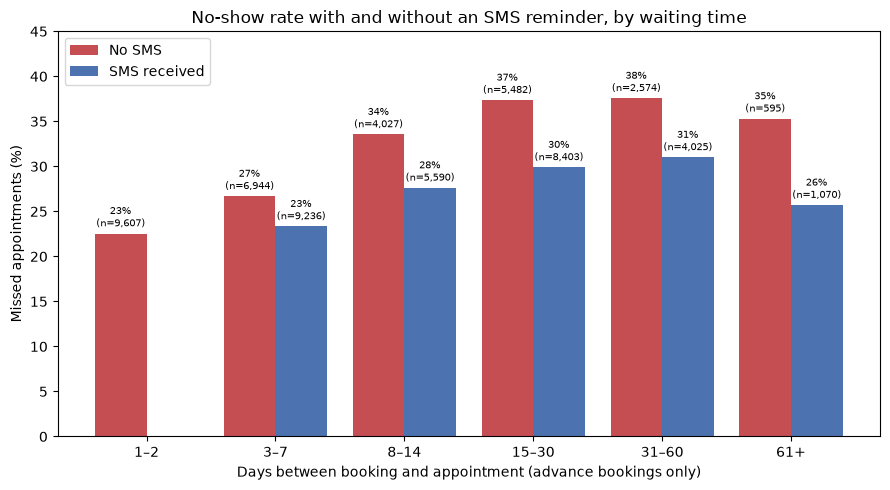

In [13]:
# a) The naive comparison
print("a) Missed rate by SMS (all training data):")
print(train.groupby("sms_received")["missed"].agg(rate="mean", n="size").round(3), "\n")

# b) Who actually gets texts? Share receiving an SMS, by waiting time
print("b) Share of appointments that received an SMS, by lead band:")
print(train.groupby("lead_band", observed=True)["sms_received"].mean().round(3), "\n")

# c) The fair comparison: SMS vs no SMS within each band (advance bookings only)
adv = train[train["lead_days"] >= 1]
q2 = (adv.groupby(["lead_band", "sms_received"], observed=True)["missed"]
         .agg(rate="mean", n="size").unstack("sms_received"))
print("c) Missed rate by SMS within each lead band:")
print(q2.round(3))

# Chart for (c)
bands = q2.index.astype(str)
x = range(len(bands))
w = 0.4
fig, ax = plt.subplots(figsize=(9, 5))
for offset, sms, colour, label in [(-w/2, 0, "#C44E52", "No SMS"), (w/2, 1, "#4C72B0", "SMS received")]:
    rates = q2[("rate", sms)] * 100
    ns = q2[("n", sms)]
    ax.bar([i + offset for i in x], rates, width=w, color=colour, label=label)
    for i, (r, n) in enumerate(zip(rates, ns)):
        if pd.notna(r):
            ax.text(i + offset, r + 0.8, f"{r:.0f}%\n(n={int(n):,})", ha="center", fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels(bands)
ax.set_ylim(0, 45)
ax.set_xlabel("Days between booking and appointment (advance bookings only)")
ax.set_ylabel("Missed appointments (%)")
ax.set_title("No-show rate with and without an SMS reminder, by waiting time")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("images/q2_sms_by_lead_time.png", dpi=150)
plt.show()

**Finding (Q2):** At first glance, SMS reminders look harmful: patients who received one missed 27.3% of appointments vs 16.7% without. This is misleading. No SMS was sent for appointments booked 0–2 days ahead, so the SMS group consists only of longer-wait patients, who miss more regardless (Q1). Comparing within the same waiting-time band reverses the picture: patients who received an SMS missed **4–9 percentage points less** in every band (e.g. 15–30 days: 30% vs 37%).

This is an example of **Simpson's paradox**: a hidden factor (waiting time) reversed the apparent effect.

**Caveat:** This is an association, not proof of cause. Within each band only ~57–64% of patients received an SMS, and the selection process is unknown; patients who received texts may differ in other ways (e.g. having a registered phone number). Only a randomised trial could isolate the effect of the reminder itself.

**Implication:** The model must include lead time alongside SMS; using SMS alone would learn the wrong direction.

### Q3. Which patient characteristics are associated with no-shows? (advance bookings only)

Overall missed rate (advance bookings): 0.284

              feature  group  rate    ci     n  median_wait
                  Age    0–4 0.318 0.014  4405         14.0
                  Age   5–12 0.307 0.012  5350         13.0
                  Age  13–17 0.364 0.017  3023         11.0
                  Age  18–29 0.352 0.010  8573         10.0
                  Age  30–44 0.316 0.008 11525         10.0
                  Age  45–59 0.244 0.007 12685          8.0
                  Age  60–74 0.200 0.008  8724          7.0
                  Age    75+ 0.215 0.014  3268          7.0
               Gender Female 0.283 0.005 38486          9.0
               Gender   Male 0.285 0.006 19067          9.0
Welfare (Scholarship)     No 0.277 0.004 52177          9.0
Welfare (Scholarship)    Yes 0.350 0.013  5376         10.0
         Hypertension     No 0.297 0.004 45380         10.0
         Hypertension    Yes 0.235 0.008 12173          7.0
             Diabetes     No 0.286 0.004 53229       

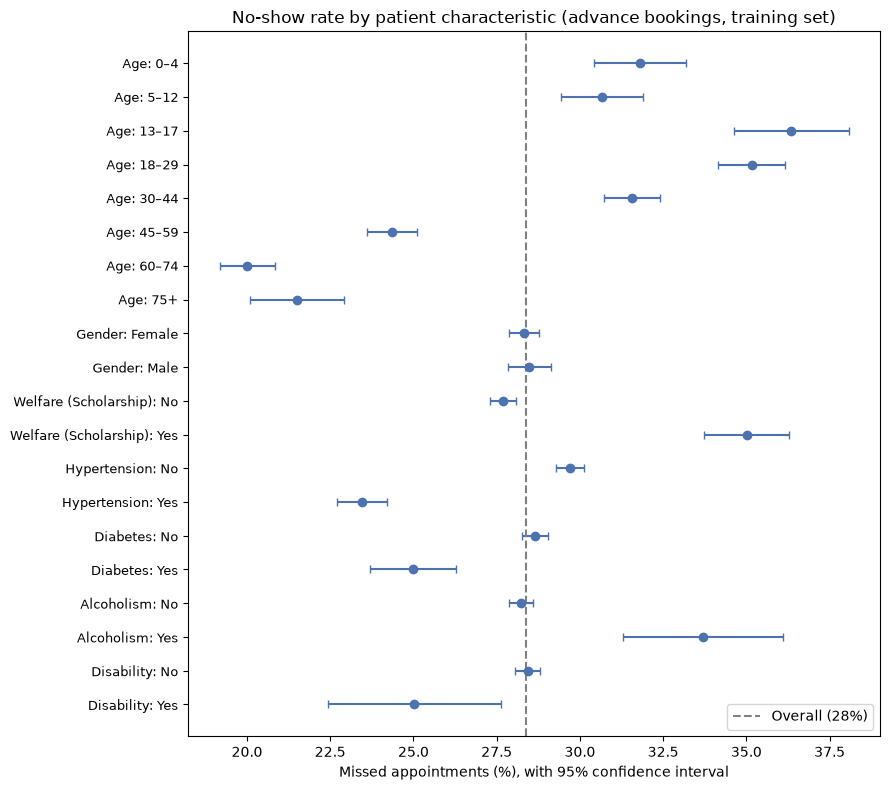

In [14]:
import numpy as np

adv = train[train["lead_days"] >= 1].copy()
adv["age_band"] = pd.cut(adv["age"], bins=[-1, 4, 12, 17, 29, 44, 59, 74, 120],
                         labels=["0–4", "5–12", "13–17", "18–29", "30–44", "45–59", "60–74", "75+"])
adv["gender_label"] = adv["gender"].map({"F": "Female", "M": "Male"})

rows = []
def add(feature, col, mapping=None):
    for level, g in adv.groupby(col, observed=True):
        p, n = g["missed"].mean(), len(g)
        ci = 1.96 * np.sqrt(p * (1 - p) / n)
        rows.append({"feature": feature,
                     "group": mapping.get(level, level) if mapping else str(level),
                     "rate": p, "ci": ci, "n": n,
                     "median_wait": g["lead_days"].median()})

add("Age", "age_band")
add("Gender", "gender_label")
yn = {0: "No", 1: "Yes"}
for feat, col in [("Welfare (Scholarship)", "scholarship"), ("Hypertension", "hypertension"),
                  ("Diabetes", "diabetes"), ("Alcoholism", "alcoholism"), ("Disability", "has_handicap")]:
    add(feat, col, yn)

q3 = pd.DataFrame(rows)
overall = adv["missed"].mean()
print(f"Overall missed rate (advance bookings): {overall:.3f}\n")
print(q3.assign(rate=q3["rate"].round(3), ci=q3["ci"].round(3)).to_string(index=False))

# Chart: rate with 95% CI for every group
labels = [f"{f}: {g}" for f, g in zip(q3["feature"], q3["group"])]
fig, ax = plt.subplots(figsize=(9, 8))

y = range(len(q3))
ax.errorbar(q3["rate"] * 100, y, xerr=q3["ci"] * 100, fmt="o", color="#4C72B0", capsize=3)
ax.axvline(overall * 100, ls="--", color="grey", label=f"Overall ({overall:.0%})")
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Missed appointments (%), with 95% confidence interval")
ax.set_title("No-show rate by patient characteristic (advance bookings, training set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/q3_patient_characteristics.png", dpi=150)
plt.show()

In [15]:
# Check 1: does the age pattern survive within the same waiting-time band?
adv["lead_band"] = pd.cut(adv["lead_days"], bins=[0, 7, 30, 200], labels=["1–7 days", "8–30 days", "31+ days"])
age_by_wait = adv.pivot_table(index="age_band", columns="lead_band", values="missed",
                              aggfunc="mean", observed=True).round(3)
print("Missed rate by age band, within each waiting-time band:")
print(age_by_wait, "\n")

# Check 2: do hypertension/diabetes still look 'protective' within the same age band?
for cond in ["hypertension", "diabetes"]:
    t = adv.pivot_table(index="age_band", columns=cond, values="missed",
                        aggfunc=["mean", "size"], observed=True)
    t.columns = [f"{stat}_{'Yes' if v == 1 else 'No'}" for stat, v in t.columns]
    print(f"{cond.capitalize()}: missed rate (and n) within each age band:")
    print(t.round(3), "\n")

Missed rate by age band, within each waiting-time band:
lead_band  1–7 days  8–30 days  31+ days
age_band                                
0–4           0.266      0.337     0.373
5–12          0.245      0.332     0.389
13–17         0.327      0.376     0.429
18–29         0.306      0.383     0.385
30–44         0.267      0.346     0.374
45–59         0.210      0.277     0.273
60–74         0.186      0.218     0.210
75+           0.181      0.240     0.280 

Hypertension: missed rate (and n) within each age band:
          mean_No  mean_Yes  size_No  size_Yes
age_band                                      
0–4         0.318     1.000     4404         1
5–12        0.306     0.400     5345         5
13–17       0.363     0.500     3007        16
18–29       0.352     0.336     8436       137
30–44       0.320     0.279    10228      1297
45–59       0.246     0.239     8521      4164
60–74       0.184     0.215     4171      4553
75+         0.188     0.232     1268      2000 

Diab

**Finding (Q3):** Overall missed rate for advance bookings: 28.4%.
- **Age** is the strongest patient-level factor: teenagers (36%) and young adults (35%) miss most; patients aged 60+ miss least (20–22%). This holds **within the same waiting-time band** (e.g. 1–7 days: 18–29 = 31% vs 60–74 = 19%), so it is not a side-effect of waiting time. Waiting time also raises risk within every age group — both factors matter independently.
- **Gender** shows no difference (28.3% vs 28.5%).
- **Welfare recipients (Scholarship)** miss more: 35.0% vs 27.7%, with similar waiting times, so it is not explained by waiting time.
- **Hypertension and diabetes** appear protective overall (e.g. hypertension 23.5% vs 29.7%), but this is explained by **age**: within the same age band the gap disappears, and among patients 60+ those with the condition miss slightly *more* (e.g. hypertension, 60–74: 21.5% vs 18.4%). Subgroup differences are modest and not formally tested.
- **Alcoholism** is associated with higher risk (33.7%, n=1,484); **disability** shows no reliable difference (25.0% ± 2.6).

**Implications:**
1. Age and waiting time must be modelled together; chronic conditions only make sense alongside age.
2. **Fairness:** welfare status and age are genuine risk factors. A model used for overbooking could systematically disadvantage poorer and younger patients. Model errors will be checked across these groups before any use is recommended.

### Q4. Do weekday and neighbourhood matter? (advance bookings only)

In [16]:
# ---- Weekday ----
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
wd = (adv.groupby(adv["appointment_date"].dt.day_name())["missed"]
         .agg(rate="mean", n="size").reindex(order))
wd["ci"] = 1.96 * np.sqrt(wd["rate"] * (1 - wd["rate"]) / wd["n"])
print("Missed rate by weekday (with 95% CI):")
print(wd.round(3), "\n")

# ---- Neighbourhood ----
nb = adv.groupby("neighbourhood")["missed"].agg(rate="mean", n="size")
nb["ci"] = 1.96 * np.sqrt(nb["rate"] * (1 - nb["rate"]) / nb["n"])
print("Neighbourhoods in training (advance bookings):", len(nb))
for cutoff in [50, 100, 200]:
    small = nb["n"] < cutoff
    print(f"  fewer than {cutoff} appointments: {small.sum()} neighbourhoods, "
          f"{nb.loc[small, 'n'].sum():,} rows ({nb.loc[small, 'n'].sum() / len(adv):.2%} of data)")

big = nb[nb["n"] >= 100].sort_values("rate")
print("\nLowest 5 (n ≥ 100):")
print(big.head(5).round(3))
print("\nHighest 5 (n ≥ 100):")
print(big.tail(5).round(3))
print(f"\nSpread among n ≥ 100: {big['rate'].min():.1%} to {big['rate'].max():.1%} "
      f"(overall {adv['missed'].mean():.1%})")

Missed rate by weekday (with 95% CI):
                   rate      n     ci
appointment_date                     
Monday            0.305  11683  0.008
Tuesday           0.283  13093  0.008
Wednesday         0.269  13646  0.007
Thursday          0.271   9044  0.009
Friday            0.292  10064  0.009
Saturday          0.348     23  0.195 

Neighbourhoods in training (advance bookings): 80
  fewer than 50 appointments: 5 neighbourhoods, 64 rows (0.11% of data)
  fewer than 100 appointments: 11 neighbourhoods, 555 rows (0.96% of data)
  fewer than 200 appointments: 19 neighbourhoods, 1,812 rows (3.15% of data)

Lowest 5 (n ≥ 100):
                  rate     n     ci
neighbourhood                      
SOLON BORGES     0.188   271  0.047
DE LOURDES       0.208   168  0.061
REPÚBLICA        0.213   431  0.039
JARDIM DA PENHA  0.218  2135  0.018
MATA DA PRAIA    0.219   366  0.042

Highest 5 (n ≥ 100):
                    rate     n     ci
neighbourhood                        
CARATOÍRA  

**Finding (Q4):**
- **Weekday:** a modest but real pattern: Monday highest (30.5% ± 0.8), Wednesday/Thursday lowest (26.9–27.1%). Saturday (n=23) is too small to interpret. Caveat: the data covers only ~6 weeks, so the pattern may reflect those specific weeks.
- **Neighbourhood:** location carries real information: among neighbourhoods with ≥100 appointments, missed rates range from 18.8% to 38.0% (overall 28.4%). 11 of 80 neighbourhoods have fewer than 100 appointments (0.96% of rows).

**Decision (cleaning plan row 7):** neighbourhoods with fewer than 100 advance-booking appointments in the training set are grouped as "OTHER". Below this size a rate is only known to within about ±9 points. Neighbourhoods that appear only in the test set are also treated as "OTHER".

**Fairness note:** neighbourhood may act as a proxy for income, like welfare status; it is included in the fairness check.

In [17]:
# ---- REPRODUCIBILITY CHECK: key results from earlier cells ----
with open("data/appointments_clean.csv", "rb") as f:
    clean_sha = hashlib.sha256(f.read()).hexdigest()

checks = {
    "Raw file SHA-256 matches certutil":  sha == EXPECTED_SHA256,
    "Clean rows = 110,516":                len(clean) == 110516,
    "Clean file SHA-256 unchanged":        clean_sha.startswith("ab148bd8"),
    "Train missed rate = 0.2012":          round(train["missed"].mean(), 4) == 0.2012,
    "Test missed rate = 0.2046":           round(test["missed"].mean(), 4) == 0.2046,
    "No patient in both sets":             set(train["patient_id"]).isdisjoint(set(test["patient_id"])),
}
for name, ok in checks.items():
    print(("PASS  " if ok else "FAIL  ") + name)
assert all(checks.values())

PASS  Raw file SHA-256 matches certutil
PASS  Clean rows = 110,516
PASS  Clean file SHA-256 unchanged
PASS  Train missed rate = 0.2012
PASS  Test missed rate = 0.2046
PASS  No patient in both sets


## Summary of exploratory findings (training set, advance bookings unless stated)

1. **Waiting time is the strongest signal.** Same-day patients (registered on arrival) miss 5%; advance bookings miss 23% at 1–2 days, rising to about a third beyond two weeks.
2. **SMS reminders: Simpson's paradox.** Naively, texted patients miss more (27% vs 17%), because texts are only sent for bookings 3+ days ahead. Within the same waiting band, texted patients miss **4–9 points less**. Association, not proven cause.
3. **Age matters independently of waiting time:** teens and young adults miss most (~35%), patients 60+ least (~20%).
4. **Welfare recipients miss more** (35% vs 28%), not explained by waiting time.
5. **Hypertension/diabetes only look protective** because their patients are older; within age bands the effect disappears.
6. **Weekday** has a modest effect (Monday highest); **neighbourhood** a substantial one (19%–38%); **gender** none.

**Carried into modelling:** model lead time and age together; evaluate on advance bookings; check fairness across welfare status, age and neighbourhood.

## Modelling decisions

- **A. Population:** the model is trained and evaluated on **advance bookings only** (lead time ≥ 1 day). Same-day appointments are registered on arrival, a different process the clinic cannot act on, and would inflate scores without adding value.
- **B. Staged features:** **Version 1 (core)** uses only information known at the moment of booking. **Version 2** adds patient-history features (e.g. prior missed appointments, other appointments on the same day), built with explicit leakage checks. Comparing V1 and V2 shows exactly what history contributes.

**Version 1 features:** lead time, age, gender, welfare (Scholarship), hypertension, diabetes, alcoholism, disability, SMS received, appointment weekday, neighbourhood (rare ones grouped as "OTHER", rule from training data only).

In [18]:
# ---- VERSION 1 FEATURES (core: known at the moment of booking) ----

# Decision A: advance bookings only (filter uses lead time, not outcomes)
train_adv = train[train["lead_days"] >= 1].copy()
test_adv  = test[test["lead_days"] >= 1].copy()

# Plan row 7: neighbourhoods kept = those with >= 100 advance bookings in TRAINING only
nb_counts = train_adv["neighbourhood"].value_counts()
KEEP_NB = set(nb_counts[nb_counts >= 100].index)

def build_features(d):
    X = pd.DataFrame(index=d.index)
    X["lead_days"]    = d["lead_days"]
    X["age"]          = d["age"]
    X["is_male"]      = (d["gender"] == "M").astype(int)
    for col in ["scholarship", "hypertension", "diabetes", "alcoholism", "has_handicap", "sms_received"]:
        X[col] = d[col]
    X["weekday"]       = d["appointment_date"].dt.day_name()
    X["neighbourhood"] = d["neighbourhood"].where(d["neighbourhood"].isin(KEEP_NB), "OTHER")
    return X

X_train, y_train = build_features(train_adv), train_adv["missed"]
X_test,  y_test  = build_features(test_adv),  test_adv["missed"]

# ---- Checks ----
assert len(KEEP_NB) == 69, f"Expected 69 kept neighbourhoods, got {len(KEEP_NB)}"
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
assert (X_train["lead_days"] >= 1).all() and (X_test["lead_days"] >= 1).all()
assert list(X_train.columns) == list(X_test.columns)

print("Neighbourhoods kept:", len(KEEP_NB), "+ OTHER")
print(f"Train: {X_train.shape[0]:,} rows, missed rate {y_train.mean():.4f}")

print(f"Test:  {X_test.shape[0]:,} rows, missed rate {y_test.mean():.4f}")
print("Train rows grouped as OTHER:", (X_train["neighbourhood"] == "OTHER").sum())
print("Test rows grouped as OTHER: ", (X_test["neighbourhood"] == "OTHER").sum())
print("\nFeatures:", list(X_train.columns))
print(X_train.head(3).to_string())

Neighbourhoods kept: 69 + OTHER
Train: 57,553 rows, missed rate 0.2837
Test:  14,402 rows, missed rate 0.2909
Train rows grouped as OTHER: 555
Test rows grouped as OTHER:  165

Features: ['lead_days', 'age', 'is_male', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'has_handicap', 'sms_received', 'weekday', 'neighbourhood']
   lead_days  age  is_male  scholarship  hypertension  diabetes  alcoholism  has_handicap  sms_received weekday neighbourhood
4          2   76        0            0             1         0           0             0             0  Friday     REPÚBLICA
5          2   23        0            0             0         0           0             0             0  Friday    GOIABEIRAS
6          2   39        0            0             0         0           0             0             0  Friday    GOIABEIRAS


## Modelling: Version 1 (core features)

Models are compared using **5-fold cross-validation on the training set only**, grouped by patient. The test set is not used until final evaluation.
Metrics: **ROC-AUC** (ranking quality; 0.5 = random) and **PR-AUC** (focus on no-shows; no-skill level = 0.284, the missed rate).

In [21]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

NUM = ["lead_days", "age"]
BIN = ["is_male", "scholarship", "hypertension", "diabetes", "alcoholism", "has_handicap", "sms_received"]
CAT = ["weekday", "neighbourhood"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("bin", "passthrough", BIN),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])

models = {
    "Dummy (no skill)": DummyClassifier(strategy="prior"),
    "Logistic regression": Pipeline([
        ("pre", preprocess),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]),
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
groups = train_adv["patient_id"]
scoring = {"ROC-AUC": "roc_auc", "PR-AUC": "average_precision"}

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, groups=groups, cv=cv, scoring=scoring)

    cv_results[name] = res
    print(f"{name:22s}  ROC-AUC {res['test_ROC-AUC'].mean():.3f} ± {res['test_ROC-AUC'].std():.3f}   "
          f"PR-AUC {res['test_PR-AUC'].mean():.3f} ± {res['test_PR-AUC'].std():.3f}")

Dummy (no skill)        ROC-AUC 0.500 ± 0.000   PR-AUC 0.284 ± 0.000
Logistic regression     ROC-AUC 0.592 ± 0.002   PR-AUC 0.354 ± 0.003


In [22]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

# Random forest: uses the same one-hot preprocessing as logistic regression
rf = Pipeline([
    ("pre", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                   class_weight="balanced", n_jobs=-1, random_state=SEED)),
])

# Gradient boosting: categories encoded as integers and handled natively
tree_pre = ColumnTransformer(
    [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT)],
    remainder="passthrough",
)
hgb = Pipeline([
    ("pre", tree_pre),
    ("clf", HistGradientBoostingClassifier(categorical_features=[0, 1], class_weight="balanced",
                                           random_state=SEED)),
])

for name, model in {"Random forest": rf, "Gradient boosting": hgb}.items():
    res = cross_validate(model, X_train, y_train, groups=groups, cv=cv, scoring=scoring)
    cv_results[name] = res
    print(f"{name:22s}  ROC-AUC {res['test_ROC-AUC'].mean():.3f} ± {res['test_ROC-AUC'].std():.3f}   "
          f"PR-AUC {res['test_PR-AUC'].mean():.3f} ± {res['test_PR-AUC'].std():.3f}")

Random forest           ROC-AUC 0.611 ± 0.004   PR-AUC 0.378 ± 0.003
Gradient boosting       ROC-AUC 0.604 ± 0.004   PR-AUC 0.373 ± 0.003


### Version 1 results (5-fold grouped cross-validation, training set)

| Model | ROC-AUC | PR-AUC |
|---|---|---|
| Dummy (no skill) | 0.500 | 0.284 |
| Logistic regression | 0.592 ± 0.002 | 0.354 ± 0.003 |
| Random forest | 0.611 ± 0.004 | 0.378 ± 0.003 |
| Gradient boosting | 0.604 ± 0.004 | 0.373 ± 0.003 |

**Interpretation:** all models beat no-skill, and tree models beat logistic regression (consistent with the non-linear age and lead-time patterns in the EDA). Random forest and gradient boosting are statistically tied. Three different model types converging at 0.59–0.61 suggests the **features**, not the algorithm, limit performance — motivating Version 2.

In [23]:
# ---- VERSION 2: PATIENT-HISTORY FEATURES (leakage-safe) ----
def history_features(d):
    base = d[["appointment_id", "patient_id", "scheduled_dt", "appointment_date", "missed"]]
    pairs = base.merge(base, on="patient_id", suffixes=("", "_o"))
    pairs = pairs[pairs["appointment_id"] != pairs["appointment_id_o"]]
    booking_day = pairs["scheduled_dt"].dt.normalize()

    # Other appointments that had already happened before this one was booked
    prior = pairs[pairs["appointment_date_o"] < booking_day]
    # Leakage check: every 'prior' appointment must be dated before the booking moment
    assert (prior["appointment_date_o"] < prior["scheduled_dt"]).all()

    # Other appointments on the same day, already booked at or before this booking
    same = pairs[(pairs["appointment_date_o"] == pairs["appointment_date"]) &
                 (pairs["scheduled_dt_o"] <= pairs["scheduled_dt"])]

    out = pd.DataFrame({"appointment_id": d["appointment_id"]})
    out = out.merge(prior.groupby("appointment_id").agg(prior_appts=("missed_o", "size"),
                                                        prior_missed=("missed_o", "sum")),
                    on="appointment_id", how="left")
    out = out.merge(same.groupby("appointment_id").size().rename("same_day_others"),
                    on="appointment_id", how="left")
    return out.fillna(0).astype({"prior_appts": int, "prior_missed": int, "same_day_others": int})

hist_train = history_features(train)   # computed on ALL training appointments
hist_test  = history_features(test)    # test patients' own history only

def add_history(X, d, hist):
    h = d[["appointment_id"]].merge(hist, on="appointment_id", how="left")
    h.index = X.index
    return X.join(h[["prior_appts", "prior_missed", "same_day_others"]])

X_train2 = add_history(X_train, train_adv, hist_train)
X_test2  = add_history(X_test,  test_adv,  hist_test)

# ---- Checks ----
assert len(X_train2) == len(X_train) and len(X_test2) == len(X_test)
assert X_train2.isna().sum().sum() == 0 and X_test2.isna().sum().sum() == 0
assert (X_train2["prior_missed"] <= X_train2["prior_appts"]).all()

for col in ["prior_appts", "prior_missed", "same_day_others"]:
    has = X_train2[col] > 0
    print(f"{col:16s} > 0 for {has.mean():6.1%} of train rows | missed rate: "
          f"{y_train[has].mean():.3f} if > 0  vs  {y_train[~has].mean():.3f} if 0")

prior_appts      > 0 for  22.9% of train rows | missed rate: 0.245 if > 0  vs  0.295 if 0
prior_missed     > 0 for   7.6% of train rows | missed rate: 0.290 if > 0  vs  0.283 if 0
same_day_others  > 0 for   6.5% of train rows | missed rate: 0.337 if > 0  vs  0.280 if 0


In [24]:
HIST = ["prior_appts", "prior_missed", "same_day_others"]

# Exact check: among patients WITH history, does missing before predict missing again?
w = X_train2["prior_appts"] > 0
mb, nm = w & (X_train2["prior_missed"] > 0), w & (X_train2["prior_missed"] == 0)
print(f"Among rows with history: missed before -> {y_train[mb].mean():.3f} (n={mb.sum():,})   "
      f"never missed -> {y_train[nm].mean():.3f} (n={nm.sum():,})\n")

# Same models as Version 1, now with history features
preprocess2 = ColumnTransformer([
    ("num", StandardScaler(), NUM + HIST),
    ("bin", "passthrough", BIN),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])
models_v2 = {
    "Logistic regression": Pipeline([("pre", preprocess2),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random forest": Pipeline([("pre", preprocess2),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                       class_weight="balanced", n_jobs=-1, random_state=SEED))]),
    "Gradient boosting": Pipeline([("pre", tree_pre),
        ("clf", HistGradientBoostingClassifier(categorical_features=[0, 1],
                                               class_weight="balanced", random_state=SEED))]),
}

cv_results_v2 = {}
print(f"{'Model':22s} {'V1 ROC':>7s} {'V2 ROC':>13s} {'V1 PR':>7s} {'V2 PR':>13s}")
for name, model in models_v2.items():
    res = cross_validate(model, X_train2, y_train, groups=groups, cv=cv, scoring=scoring)
    cv_results_v2[name] = res
    v1 = cv_results[name]
    print(f"{name:22s} {v1['test_ROC-AUC'].mean():7.3f} "

          f"{res['test_ROC-AUC'].mean():7.3f}±{res['test_ROC-AUC'].std():.3f} "
          f"{v1['test_PR-AUC'].mean():7.3f} "
          f"{res['test_PR-AUC'].mean():7.3f}±{res['test_PR-AUC'].std():.3f}")

Among rows with history: missed before -> 0.290 (n=4,383)   never missed -> 0.222 (n=8,801)

Model                   V1 ROC        V2 ROC   V1 PR         V2 PR
Logistic regression      0.592   0.597±0.003   0.354   0.357±0.005
Random forest            0.611   0.613±0.004   0.378   0.379±0.004
Gradient boosting        0.604   0.605±0.004   0.373   0.374±0.005


### Version 2 results: does patient history help?

Among training rows with history, patients who had missed before missed again 29.0% of the time (n=4,383) vs 22.2% for those who never missed (n=8,801) — a real signal. However:

| Model | V1 ROC-AUC | V2 ROC-AUC | V1 PR-AUC | V2 PR-AUC |
|---|---|---|---|---|
| Logistic regression | 0.592 | 0.597 ± 0.003 | 0.354 | 0.357 ± 0.005 |
| Random forest | 0.611 | 0.613 ± 0.004 | 0.378 | 0.379 ± 0.004 |
| Gradient boosting | 0.604 | 0.605 ± 0.004 | 0.373 | 0.374 ± 0.005 |

**Interpretation:** gains are within cross-validation noise for the tree models. History covers only 23% of rows (7.6% with a prior miss) because the data spans ~6 weeks; with longer records the benefit would likely be larger. Note also that `prior_appts` partly reflects shorter waits, an artefact of the narrow date window.

**Decision:** the final model is **Random forest, Version 1 (core features)** — the best-performing model, statistically tied with its V2 counterpart, and simpler with no history-related leakage risk.

### Tuning the random forest (V1)

Small grid search inside the same 5-fold grouped cross-validation (training set only).
**Rule, fixed in advance:** primary metric PR-AUC; a setting replaces the defaults (min_samples_leaf=20, max_features="sqrt") only if it improves mean PR-AUC by more than the cross-validation noise (~0.004).

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__min_samples_leaf": [10, 20, 50, 100],
    "clf__max_features": ["sqrt", 0.5],
}
search = GridSearchCV(rf, param_grid, scoring=scoring, refit="PR-AUC", cv=cv)
search.fit(X_train, y_train, groups=groups)

r = pd.DataFrame(search.cv_results_)
table = pd.DataFrame({
    "min_samples_leaf": r["param_clf__min_samples_leaf"],
    "max_features":     r["param_clf__max_features"].astype(str),
    "PR-AUC":           r["mean_test_PR-AUC"].round(3),
    "PR ±":             r["std_test_PR-AUC"].round(3),
    "ROC-AUC":          r["mean_test_ROC-AUC"].round(3),
}).sort_values("PR-AUC", ascending=False)
print(table.to_string(index=False))

default = table[(table["min_samples_leaf"] == 20) & (table["max_features"] == "sqrt")].iloc[0]
best = table.iloc[0]
gain = best["PR-AUC"] - default["PR-AUC"]
print(f"\nDefault PR-AUC {default['PR-AUC']:.3f} | best PR-AUC {best['PR-AUC']:.3f} "
      f"({best['min_samples_leaf']}, {best['max_features']}) | gain {gain:+.3f}")
print("Decision by pre-set rule:", "ADOPT best" if gain > 0.004 else "KEEP defaults")

 min_samples_leaf max_features  PR-AUC  PR ±  ROC-AUC
               10         sqrt   0.378 0.004    0.611
               20         sqrt   0.378 0.003    0.611
               50         sqrt   0.374 0.004    0.609
              100         sqrt   0.372 0.003    0.607
               20          0.5   0.372 0.002    0.604
               50          0.5   0.372 0.004    0.606
              100          0.5   0.370 0.004    0.606
               10          0.5   0.369 0.001    0.601

Default PR-AUC 0.378 | best PR-AUC 0.378 (10, sqrt) | gain +0.000
Decision by pre-set rule: KEEP defaults


**Tuning result:** the defaults (min_samples_leaf=20, max_features="sqrt") tie for best (PR-AUC 0.378); gain +0.000, so by the pre-set rule the defaults are kept. All 8 settings fall within 0.369–0.378, further evidence that the available features, not model settings, limit performance.

In [26]:
from sklearn.model_selection import cross_val_predict

# Every training appointment scored by a model that never saw it
oof = cross_val_predict(rf, X_train, y_train, groups=groups, cv=cv, method="predict_proba")[:, 1]
y = y_train.to_numpy()
assert len(oof) == len(y)

base = y.mean()
print(f"Without the model: {base:.1%} of patients miss. Contacting patients at random catches no-shows "
      f"in proportion to effort.\n")
print(f"{'Contact top':>11s} {'Precision':>10s} {'Recall':>8s} {'Lift':>6s}   Per 100 appointments")
for share in [0.10, 0.20, 0.30, 0.40, 0.50]:
    flag = oof >= np.quantile(oof, 1 - share)
    tp = (flag & (y == 1)).sum()
    precision, recall = tp / flag.sum(), tp / y.sum()
    per100 = flag.mean() * 100
    print(f"{share:>11.0%} {precision:>10.1%} {recall:>8.1%} {precision / base:>5.2f}x   "
          f"contact {per100:.0f}: reach {precision * per100:.1f} no-shows, "
          f"{(1 - precision) * per100:.1f} would have attended anyway")

Without the model: 28.4% of patients miss. Contacting patients at random catches no-shows in proportion to effort.

Contact top  Precision   Recall   Lift   Per 100 appointments
        10%      44.5%    15.7%  1.57x   contact 10: reach 4.4 no-shows, 5.6 would have attended anyway
        20%      40.6%    28.6%  1.43x   contact 20: reach 8.1 no-shows, 11.9 would have attended anyway
        30%      38.3%    40.5%  1.35x   contact 30: reach 11.5 no-shows, 18.5 would have attended anyway
        40%      36.3%    51.1%  1.28x   contact 40: reach 14.5 no-shows, 25.5 would have attended anyway
        50%      34.7%    61.2%  1.22x   contact 50: reach 17.4 no-shows, 32.6 would have attended anyway


In [27]:
print(f"{'Contact top':>11s} {'Precision':>10s} {'Recall':>8s} {'Lift':>6s}")
for share in [0.60, 0.70, 0.80]:
    flag = oof >= np.quantile(oof, 1 - share)
    tp = (flag & (y == 1)).sum()
    precision, recall = tp / flag.sum(), tp / y.sum()
    print(f"{share:>11.0%} {precision:>10.1%} {recall:>8.1%} {precision / base:>5.2f}x")

Contact top  Precision   Recall   Lift
        60%      33.4%    70.6%  1.18x
        70%      32.2%    79.4%  1.13x
        80%      30.8%    86.9%  1.09x


## Operating strategy: how a clinic would use the model

Out-of-fold predictions on the training set show the model's value depends on how many patients are contacted:

| Contact top | Precision | Recall | Lift vs random |
|---|---|---|---|
| 10% | 44.5% | 15.7% | 1.57x |
| 20% | 40.6% | 28.6% | 1.43x |
| 70% | 32.2% | 79.4% | 1.13x |
| 80% | 30.8% | 86.9% | 1.09x |

In the author's facility, routine reminders are automated SMS reaching most patients, while personal calls go to a selected few based on the nature of the appointment. This suggests a **two-tier strategy**:
1. **Tier 1 — automated SMS to all reachable patients.** No model needed: at 70–80% coverage the model is barely better than random (1.09–1.13x).
2. **Tier 2 — a personal call for the riskiest 10%**, in addition to calls already made on clinical grounds. Here the model makes call effort about **1.6x** as productive as random selection.

The model **complements, not replaces**, clinical judgement on who receives calls.
**Operating point:** top 10% by risk score. The threshold is fixed from training predictions *before* the test set is used.

In [28]:
# Freeze the operating threshold from TRAINING out-of-fold scores
OPERATING_SHARE = 0.10
THRESHOLD = float(np.quantile(oof, 1 - OPERATING_SHARE))
print(f"Frozen threshold (top {OPERATING_SHARE:.0%} of training risk scores): {THRESHOLD:.4f}")
print("Note: this is a model score, not a calibrated probability "
      "(class_weight='balanced' shifts scores upwards).")

Frozen threshold (top 10% of training risk scores): 0.6030
Note: this is a model score, not a calibrated probability (class_weight='balanced' shifts scores upwards).


## Final evaluation on the held-out test set (run once)

The final model (Random forest, V1 features, default settings) is trained on the full training set and evaluated once on the untouched test set, using the threshold frozen from training. No changes are made after seeing these results.

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import clone

final_model = clone(rf).fit(X_train, y_train)
test_scores = final_model.predict_proba(X_test)[:, 1]
yt = y_test.to_numpy()
test_base = yt.mean()

roc = roc_auc_score(yt, test_scores)
pr = average_precision_score(yt, test_scores)
print(f"Test set: {len(yt):,} advance bookings, missed rate {test_base:.1%}\n")
print(f"ROC-AUC: {roc:.3f}   (cross-validation estimate 0.611 ± 0.004; random = 0.500)")
print(f"PR-AUC:  {pr:.3f}   (cross-validation estimate 0.378 ± 0.003; no-skill on test = {test_base:.3f})")

# Apply the FROZEN threshold
flag = test_scores >= THRESHOLD
tp = (flag & (yt == 1)).sum()
precision, recall = tp / flag.sum(), tp / yt.sum()
print(f"\nAt the frozen threshold ({THRESHOLD:.4f}):")
print(f"  Flagged for a call: {flag.sum():,} appointments ({flag.mean():.1%} of test)")
print(f"  Precision: {precision:.1%}   Recall: {recall:.1%}   Lift vs random: {precision / test_base:.2f}x")
print(f"  (Training expectation at top 10%: precision 44.5%, lift 1.57x)")

Test set: 14,402 advance bookings, missed rate 29.1%

ROC-AUC: 0.605   (cross-validation estimate 0.611 ± 0.004; random = 0.500)
PR-AUC:  0.375   (cross-validation estimate 0.378 ± 0.003; no-skill on test = 0.291)

At the frozen threshold (0.6030):
  Flagged for a call: 1,544 appointments (10.7% of test)
  Precision: 43.2%   Recall: 15.9%   Lift vs random: 1.48x
  (Training expectation at top 10%: precision 44.5%, lift 1.57x)


### Final test result

| Metric | Cross-validation (training) | Test (unseen patients) |
|---|---|---|
| ROC-AUC | 0.611 ± 0.004 | **0.605** |
| PR-AUC | 0.378 ± 0.003 | **0.375** (no-skill: 0.291) |
| Share flagged at frozen threshold | 10% | **10.7%** (1,544 appointments) |
| Precision | 44.5% | **43.2%** |
| Recall | 15.7% | **15.9%** |
| Lift vs random | 1.57x | **1.48x** |

**Interpretation:** test performance is close to, and slightly below, the cross-validation estimates — the expected pattern for unseen data, confirming that model selection did not overfit and no information leaked from the test set.

**In practice:** calling the 1,544 flagged patients would reach about 667 who would otherwise miss their appointment, versus about 449 if the same number were chosen at random — roughly 218 more calls reaching patients who need them, making call effort about 1.5x as productive.

**Limitations:** performance is modest (ROC-AUC ≈ 0.6); the data covers one Brazilian city over ~6 weeks in 2016; and the score is a ranking, not a calibrated probability.

## Fairness check (test set, frozen model, audit only)

Whether a flag is a benefit or a burden depends on its use:
- **Supportive call (Tier 2):** flagging is a benefit; the risk is *under-serving* a group → compare **recall** (share of each group's no-shows reached).
- **Overbooking:** flagging is a burden; the risk is *wrongly burdening* a group → compare **false positive rate** (share of each group's attenders who were flagged).

Nothing in the model is changed based on this audit.

In [30]:
ev = test_adv[["age", "gender", "scholarship", "neighbourhood"]].copy()
ev["missed"] = yt
ev["flag"] = test_scores >= THRESHOLD
ev["age_band"] = pd.cut(ev["age"], bins=[-1, 17, 29, 44, 59, 120],
                        labels=["0–17", "18–29", "30–44", "45–59", "60+"])
ev["welfare"] = ev["scholarship"].map({0: "No", 1: "Yes"})
ev["sex"] = ev["gender"].map({"F": "Female", "M": "Male"})

def fairness_table(col):
    rows = []
    for level, g in ev.groupby(col, observed=True):
        pos, neg = g["missed"] == 1, g["missed"] == 0
        rows.append({
            col: level, "n": len(g),
            "actual miss": g["missed"].mean(),
            "flagged": g["flag"].mean(),
            "precision": (g["flag"] & pos).sum() / max(g["flag"].sum(), 1),
            "recall (benefit)": (g["flag"] & pos).sum() / max(pos.sum(), 1),
            "FPR (burden)": (g["flag"] & neg).sum() / max(neg.sum(), 1),
        })
    t = pd.DataFrame(rows)
    fmt = {c: "{:.1%}".format for c in t.columns if c not in (col, "n")}
    print(t.to_string(index=False, formatters=fmt), "\n")

print(f"Overall: flagged {ev['flag'].mean():.1%}, recall {recall:.1%}, "
      f"FPR {(ev['flag'] & (ev['missed'] == 0)).sum() / (ev['missed'] == 0).sum():.1%}\n")
for col in ["welfare", "age_band", "sex"]:
    fairness_table(col)

# Neighbourhoods: compare flag rates across neighbourhoods with >= 100 test appointments
nb = ev.groupby("neighbourhood").agg(n=("flag", "size"), actual=("missed", "mean"), flagged=("flag", "mean"))
nb = nb[nb["n"] >= 100].sort_values("flagged")
print(f"Neighbourhoods with >= 100 test appointments: {len(nb)}")
print("Least flagged:\n", nb.head(3).round(3).to_string(), "\n")
print("Most flagged:\n", nb.tail(3).round(3).to_string(), "\n")
print("Correlation between neighbourhood actual miss rate and flag rate:",
      round(nb["actual"].corr(nb["flagged"]), 2))

Overall: flagged 10.7%, recall 15.9%, FPR 8.6%

welfare     n actual miss flagged precision recall (benefit) FPR (burden)
     No 13107       28.5%    9.5%     43.0%            14.4%         7.6%
    Yes  1295       34.8%   22.6%     44.0%            28.6%        19.4% 

age_band    n actual miss flagged precision recall (benefit) FPR (burden)
    0–17 3388       31.8%   19.1%     41.8%            25.1%        16.3%
   18–29 2203       36.5%   19.7%     45.5%            24.5%        16.9%
   30–44 2886       31.3%   14.8%     41.2%            19.5%        12.7%
   45–59 3070       26.4%    1.0%     59.4%             2.3%         0.6%
     60+ 2855       20.9%    0.2%     83.3%             0.8%         0.0% 

   sex    n actual miss flagged precision recall (benefit) FPR (burden)
Female 9580       28.9%   10.4%     42.4%            15.2%         8.4%
  Male 4822       29.4%   11.4%     44.6%            17.3%         9.0% 

Neighbourhoods with >= 100 test appointments: 47
Least flagged:


### Fairness findings

- **Sex:** no meaningful disparity (flagged 10.4% vs 11.4%; recall 15.2% vs 17.3%; FPR 8.4% vs 9.0%).
- **Welfare (Scholarship):** recipients miss 1.2x as often (34.8% vs 28.5%) but are flagged 2.4x as often (22.6% vs 9.5%). Precision is equal (44.0% vs 43.0%). For supportive calls, their no-shows are reached twice as often (recall 28.6% vs 14.4%); for overbooking, their attenders would be wrongly burdened 2.5x as often (FPR 19.4% vs 7.6%).
- **Age:** strongly amplified. Patients 45–59 and 60+ miss 26.4% and 20.9% of appointments, yet only 1.0% and 0.2% are flagged (recall 2.3% and 0.8%). Selecting the top 10% fills almost entirely with younger patients, so older patients' no-shows — often chronic-disease follow-ups — are almost never reached.
- **Neighbourhood:** flag rates only partly follow actual risk (correlation 0.51); e.g. Jardim da Penha (25.4% actual) receives no flags, Jesus de Nazareth (35.8%) receives 42.3%.

**Why:** top-k selection amplifies group differences in average risk. When groups have different base rates, equal precision and equal error rates cannot all be achieved simultaneously, so trade-offs must be made explicit.

**Recommendations:**
1. **Use the model only for supportive actions** (extra reminder calls). **Do not use it for overbooking**, where it would disproportionately burden welfare recipients and younger patients who would have attended.
2. **Keep clinical-ground calls alongside the model** — they likely reach the older, chronic-care patients the model almost never flags.
3. A possible extension is **allocating calls within age groups** (e.g. the top 10% of each age band), trading some overall precision for broader coverage. This would need to be designed and evaluated on training data before any test-set use.

## Robustness check: one row per booking group (cleaning plan row 10)

Same-second multi-bookings (same patient, booking time and appointment day) were kept because they could not be proven duplicates. Here results are recomputed keeping only the first row of each group. Audit only — the final model, features and threshold are unchanged.

In [31]:
key = ["patient_id", "scheduled_dt", "appointment_date"]
tr_keep = ~train_adv.duplicated(key, keep="first")
te_keep = ~test_adv.duplicated(key, keep="first")
print(f"Train: {len(train_adv):,} -> {tr_keep.sum():,} rows ({(~tr_keep).sum():,} removed)")
print(f"Test:  {len(test_adv):,} -> {te_keep.sum():,} rows ({(~te_keep).sum():,} removed)\n")

# 1. Cross-validation on de-duplicated training data (same model, same folds setup)
Xd, yd, gd = X_train[tr_keep], y_train[tr_keep], train_adv.loc[tr_keep, "patient_id"]
res_d = cross_validate(rf, Xd, yd, groups=gd, cv=cv, scoring=scoring)
print(f"CV, all rows:     ROC-AUC 0.611   PR-AUC 0.378   (missed rate {y_train.mean():.3f})")
print(f"CV, de-duplicated: ROC-AUC {res_d['test_ROC-AUC'].mean():.3f}   "
      f"PR-AUC {res_d['test_PR-AUC'].mean():.3f}   (missed rate {yd.mean():.3f})\n")

# 2. Frozen final model on de-duplicated test data
s, yy = test_scores[te_keep.to_numpy()], yt[te_keep.to_numpy()]
f = s >= THRESHOLD
tp = (f & (yy == 1)).sum()
print(f"Test, all rows:     ROC-AUC 0.605   PR-AUC 0.375   precision 43.2%   lift 1.48x")
print(f"Test, de-duplicated: ROC-AUC {roc_auc_score(yy, s):.3f}   "
      f"PR-AUC {average_precision_score(yy, s):.3f}   "
      f"precision {tp / f.sum():.1%}   lift {(tp / f.sum()) / yy.mean():.2f}x   "
      f"(flagged {f.mean():.1%}, missed rate {yy.mean():.3f})")

Train: 57,553 -> 56,547 rows (1,006 removed)
Test:  14,402 -> 14,145 rows (257 removed)

CV, all rows:     ROC-AUC 0.611   PR-AUC 0.378   (missed rate 0.284)
CV, de-duplicated: ROC-AUC 0.613   PR-AUC 0.377   (missed rate 0.282)

Test, all rows:     ROC-AUC 0.605   PR-AUC 0.375   precision 43.2%   lift 1.48x
Test, de-duplicated: ROC-AUC 0.605   PR-AUC 0.374   precision 43.2%   lift 1.49x   (flagged 10.5%, missed rate 0.290)


**Robustness result:** keeping one row per booking group (removing 1,006 training and 257 test rows) leaves all results unchanged within noise: CV ROC-AUC 0.611 → 0.613, PR-AUC 0.378 → 0.377; test ROC-AUC 0.605 → 0.605, PR-AUC 0.375 → 0.374, precision 43.2% → 43.2%, lift 1.48x → 1.49x. The decision to keep same-second multi-bookings (cleaning plan row 10) does not affect any conclusion.

## What drives the predictions? (permutation importance, test set, audit only)

Each feature is shuffled in turn (5 repeats) and the drop in PR-AUC is measured. A larger drop means the model relies more on that feature.

      feature  PR-AUC drop      ±
    lead_days       0.0366 0.0029
          age       0.0341 0.0020
neighbourhood       0.0188 0.0027
 sms_received       0.0102 0.0014
      weekday       0.0055 0.0008
 hypertension       0.0026 0.0009
   alcoholism       0.0016 0.0003
  scholarship       0.0005 0.0006
 has_handicap       0.0004 0.0004
     diabetes       0.0001 0.0004
      is_male      -0.0001 0.0007


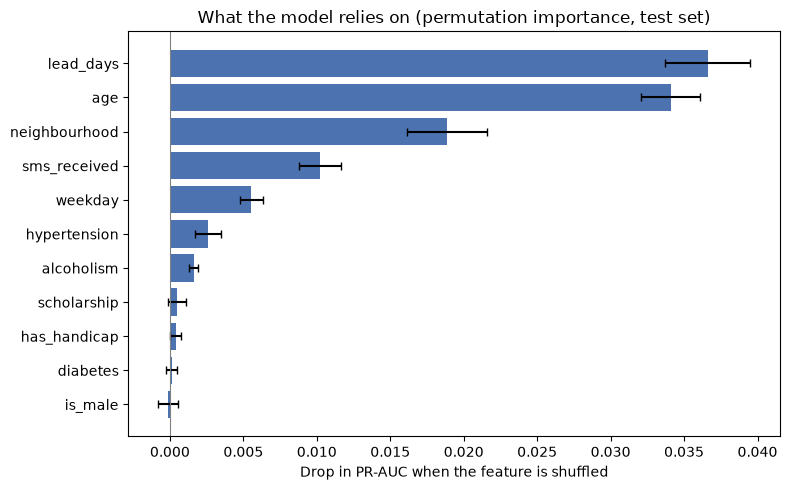

In [32]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(final_model, X_test, y_test, scoring="average_precision",
                            n_repeats=5, random_state=SEED, n_jobs=1)
imp = (pd.DataFrame({"feature": X_test.columns,
                     "PR-AUC drop": pi.importances_mean,
                     "±": pi.importances_std})
         .sort_values("PR-AUC drop", ascending=False))
print(imp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"], imp["PR-AUC drop"], xerr=imp["±"], color="#4C72B0", capsize=3)
ax.invert_yaxis()
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Drop in PR-AUC when the feature is shuffled")
ax.set_title("What the model relies on (permutation importance, test set)")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150)
plt.show()

**Findings:**
- The model relies most on **lead time** (PR-AUC drop 0.037) and **age** (0.034), then **neighbourhood** (0.019), **SMS** (0.010) and **weekday** (0.006). Health flags contribute little; **sex** contributes nothing — all consistent with the exploratory analysis.
- **Welfare status has near-zero importance (0.0005 ± 0.0006)**, yet recipients are flagged 2.4x as often (fairness check). The most likely explanation is that welfare status is largely captured through **neighbourhood and age**, so the model can do without the explicit column.
- **Implication:** removing a sensitive column ("fairness through unawareness") would likely not remove the disparity, because the information flows through proxies. Fairness must be addressed through *how the model is used* — supportive actions only, alongside clinical judgement — not by deleting columns.

**Caveat:** permutation importance splits credit among correlated features; low importance means the model can do without a feature, not that the feature is unrelated to no-shows.